# Notebook 05 — Base de Sentimentos com Lags para Modelagem

**Objetivo**: construir uma base mensal de sentimento/tom dos documentos do Banco Central e gerar variáveis defasadas até 6 meses para uso no Notebook 06.

A escolha do melhor modelo de sentimento **não será feita neste notebook**. Aqui são geradas as variáveis e realizadas análises diagnósticas de correlação. A decisão final sobre quais variáveis usar deve ocorrer no **Notebook 06**, com base no desempenho preditivo dos modelos, especialmente pelo **RMSE** — raiz do erro quadrático médio.

**Entradas**:
- `base_series.csv`: série mensal de inadimplência;
- `base_sentimentos.csv`: base consolidada de sentimentos do Notebook 04.

**Saída principal**:
- `base_sentimento_lags_todos_relatorios.csv`: base única com todos os relatórios, todos os modelos de sentimento e lags de 1 a 6 meses. As colunas recebem prefixo do tipo de relatório, por exemplo: `copom_score_mistral_L1` e `estatisticas_score_mistral_L1`.

In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


## 1. Carregamento das bases

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Série de Inadimplência (Notebook 01) ────────────────────────────────────
URL_INAD = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_series.csv"
try:
    df_inad = pd.read_csv("base_series.csv")
    print("base_series.csv carregado do disco.")
except FileNotFoundError:
    df_inad = pd.read_csv(URL_INAD)
    print("base_series.csv carregado do GitHub.")


# ── Scores de Sentimento (Notebook 04) ──────────────────────────────────────
URL_SENT = "https://raw.githubusercontent.com/akemitti/Pred-inad-credito/main/base_sentimentos.csv"
try:
    df_sent = pd.read_csv("base_sentimentos.csv")
    print("base_sentimentos.csv carregado do disco.")
except FileNotFoundError:
    df_sent = pd.read_csv(URL_SENT)
    print("base_sentimentos.csv carregado do GitHub.")

df_sent.columns = [c.strip().lower() for c in df_sent.columns]
df_sent["data"] = pd.to_datetime(df_sent["data"], errors="coerce")

# Identificar colunas de score
score_cols_raw = [c for c in df_sent.columns if c.startswith("score_")]
print(f"Scores disponíveis: {score_cols_raw}")


base_series.csv carregado do disco.
base_sentimentos.csv carregado do disco.
Scores disponíveis: ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']


In [13]:
df_inad

,mes,inad_total,inad_total_lag1,inad_total_lag2,inad_total_lag3,inad_total_lag4,inad_total_lag5,inad_total_lag6
0,2019-07-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95
1,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91
2,2019-09-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99
3,2019-10-01,3.03,3.06,3.04,3.06,2.95,3.05,3.02
4,2019-11-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05
...,...,...,...,...,...,...,...,...
73,2025-08-01,3.95,3.77,3.57,3.54,3.50,3.28,3.26
74,2025-09-01,3.91,3.95,3.77,3.57,3.54,3.50,3.28
75,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50
76,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54


In [11]:
df_sent

,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.000000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.000000,-0.062500,-0.336417,0.50
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.062500,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.000000,-0.187500,-0.407422,0.75
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.000000,0.062500,-0.227865,0.75
...,...,...,...,...,...,...,...,...,...
129,2025-08-01,estatisticas,202508_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9894,0.000000,-0.916667,-0.018209,-0.10
130,2025-09-01,estatisticas,202509_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9776,0.050000,-1.000000,0.007749,-0.60
131,2025-10-01,estatisticas,202510_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9920,-0.400000,-1.000000,-0.007200,0.65
132,2025-11-01,estatisticas,202511_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9898,-0.266667,-1.000000,0.292047,-0.30


## 2. Agregação mensal com grade completa e interpolação

A série de inadimplência é mensal. Como as **Atas do Copom** não ocorrem exatamente todos os meses — em geral, seguem o calendário de reuniões do Copom, que pode ocorrer em intervalos próximos de 45 dias — é necessário transformar o sentimento das atas em uma série mensal contínua.

A regra aplicada neste notebook é:

1. agregar os scores de sentimento por mês e por tipo de relatório;
2. criar uma grade mensal completa de `2019-01-01` até `2025-12-01`;
3. garantir que, para todos os meses, exista valor de sentimento para as **Atas do Copom**, usando interpolação linear para preencher lacunas internas;
4. aplicar `bfill/ffill` — preenchimento com o valor seguinte/anterior — apenas nas bordas da série, quando necessário;
5. manter colunas de rastreabilidade para identificar quais meses eram observados originalmente e quais foram preenchidos.

Os Relatórios de Estatísticas também são mantidos na base consolidada, mas o ponto metodológico mais importante aqui é a mensalização das Atas do Copom para compatibilização com a série mensal de inadimplência.

In [14]:
df_sent_completo = df_sent.copy()

# ── Padronização da identificação do tipo de relatório ──────────────────────
if "tipo_relatorio" not in df_sent_completo.columns:
    if "tipo" in df_sent_completo.columns:
        df_sent_completo["tipo_relatorio"] = df_sent_completo["tipo"]
    else:
        raise ValueError(
            "A coluna 'tipo_relatorio' não foi encontrada na base_sentimentos.csv. "
            "Verifique se o Notebook 04 exportou a base consolidada corretamente."
        )

df_sent_completo["tipo_relatorio"] = (
    df_sent_completo["tipo_relatorio"]
    .astype(str)
    .str.lower()
    .str.strip()
)

TIPOS_VALIDOS = ["copom", "estatisticas"]
df_sent_completo = df_sent_completo[
    df_sent_completo["tipo_relatorio"].isin(TIPOS_VALIDOS)
].copy()

# ── Padronização da data e dos scores ───────────────────────────────────────
df_sent_completo["data"] = pd.to_datetime(df_sent_completo["data"], errors="coerce")
df_sent_completo = df_sent_completo.dropna(subset=["data"])

# Garantir que os scores sejam numéricos
for col in score_cols_raw:
    df_sent_completo[col] = pd.to_numeric(df_sent_completo[col], errors="coerce")

score_cols = [c for c in score_cols_raw if df_sent_completo[c].notna().any()]

print("Scores válidos para análise:")
print(score_cols)

print("\nDistribuição da base completa por tipo de relatório:")
display(
    df_sent_completo["tipo_relatorio"]
    .value_counts()
    .rename_axis("tipo_relatorio")
    .reset_index(name="qtd_registros")
)

# ── Grade mensal completa ───────────────────────────────────────────────────
PERIODO_INICIO = "2019-01-01"
PERIODO_FIM = "2025-12-01"

grade_mensal = pd.date_range(
    start=PERIODO_INICIO,
    end=PERIODO_FIM,
    freq="MS"
)

print(f"\nGrade mensal esperada: {len(grade_mensal)} meses")
print(f"Período: {grade_mensal.min().date()} a {grade_mensal.max().date()}")


def agregar_mensal_com_interpolacao(df_base, tipo_relatorio, score_cols, grade_mensal):
    """
    Agrega os scores por mês para um tipo de relatório e garante uma série mensal completa.

    Para as Atas do Copom, essa etapa é essencial porque as atas não são mensais.
    A interpolação linear preenche lacunas internas entre observações conhecidas.
    """
    df_tipo = df_base[df_base["tipo_relatorio"] == tipo_relatorio].copy()

    if df_tipo.empty:
        raise ValueError(f"Não há registros para tipo_relatorio = '{tipo_relatorio}'.")

    df_tipo["mes"] = df_tipo["data"].dt.to_period("M").dt.to_timestamp()

    # Agregação mensal: se houver mais de um documento no mesmo mês, usa a média.
    df_obs = (
        df_tipo.groupby("mes")[score_cols]
        .mean()
        .sort_index()
    )

    meses_observados = set(df_obs.index)

    # Grade mensal completa
    df_mensal = df_obs.reindex(grade_mensal)
    df_mensal.index.name = "data"
    df_mensal = df_mensal.reset_index()

    df_mensal["tipo_relatorio"] = tipo_relatorio
    df_mensal["registro_original"] = df_mensal["data"].isin(meses_observados)
    df_mensal["mes_ausente_originalmente"] = ~df_mensal["registro_original"]

    # Preenchimento das lacunas internas
    scores_interpolados = df_mensal[score_cols].interpolate(
        method="linear",
        limit_area="inside"
    )

    # Preenchimento de bordas, quando necessário
    scores_preenchidos = scores_interpolados.bfill().ffill()

    df_mensal[score_cols] = scores_preenchidos

    # Rastreabilidade do método de preenchimento
    df_mensal["metodo_preenchimento"] = "observado"

    mask_interpolado = (
        df_mensal["mes_ausente_originalmente"]
        & scores_interpolados.notna().any(axis=1)
    )
    df_mensal.loc[mask_interpolado, "metodo_preenchimento"] = "interpolacao_linear"

    mask_borda = (
        df_mensal["mes_ausente_originalmente"]
        & ~mask_interpolado
    )
    df_mensal.loc[mask_borda, "metodo_preenchimento"] = "bfill_ffill_borda"

    return df_mensal


# Gerar base mensal completa para cada tipo de relatório
dfs_mensais = []
for tipo in TIPOS_VALIDOS:
    df_tipo_mensal = agregar_mensal_com_interpolacao(
        df_base=df_sent_completo,
        tipo_relatorio=tipo,
        score_cols=score_cols,
        grade_mensal=grade_mensal
    )
    dfs_mensais.append(df_tipo_mensal)

df_sent_mensal = pd.concat(dfs_mensais, ignore_index=True)

# Verificação da cobertura mensal
resumo_cobertura = (
    df_sent_mensal
    .groupby("tipo_relatorio")
    .agg(
        meses_total=("data", "nunique"),
        registros_originais=("registro_original", "sum"),
        meses_preenchidos=("mes_ausente_originalmente", "sum")
    )
    .reset_index()
)

print("\n=== Cobertura mensal após interpolação ===")
display(resumo_cobertura)

print("\nMétodo de preenchimento por tipo de relatório:")
display(
    df_sent_mensal
    .groupby(["tipo_relatorio", "metodo_preenchimento"])
    .size()
    .reset_index(name="qtd_meses")
)

# Checagem específica solicitada pelo professor: Copom deve ter todos os meses.
qtd_meses_copom = df_sent_mensal.query("tipo_relatorio == 'copom'")["data"].nunique()
assert qtd_meses_copom == len(grade_mensal), (
    f"Copom deveria ter {len(grade_mensal)} meses, mas tem {qtd_meses_copom}."
)

print(f"\n✅ Série mensal do Copom completa: {qtd_meses_copom} meses.")
display(df_sent_mensal.head())

Scores válidos para análise:
['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']

Distribuição da base completa por tipo de relatório:


,tipo_relatorio,qtd_registros
0,estatisticas,81
1,copom,53



Grade mensal esperada: 84 meses
Período: 2019-01-01 a 2025-12-01

=== Cobertura mensal após interpolação ===


,tipo_relatorio,meses_total,registros_originais,meses_preenchidos
0,copom,84,53,31
1,estatisticas,84,81,3



Método de preenchimento por tipo de relatório:


,tipo_relatorio,metodo_preenchimento,qtd_meses
0,copom,bfill_ffill_borda,1
1,copom,interpolacao_linear,30
2,copom,observado,53
3,estatisticas,interpolacao_linear,3
4,estatisticas,observado,81



✅ Série mensal do Copom completa: 84 meses.


,data,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento
0,2019-01-01,-0.7783,0.00000,-0.071429,-0.248734,0.500,copom,False,True,bfill_ffill_borda
1,2019-02-01,-0.7783,0.00000,-0.071429,-0.248734,0.500,copom,True,False,observado
2,2019-03-01,-0.6808,0.00000,-0.062500,-0.336417,0.500,copom,True,False,observado
3,2019-04-01,-0.8041,0.03125,-0.093750,-0.362641,0.575,copom,False,True,interpolacao_linear
4,2019-05-01,-0.9274,0.06250,-0.125000,-0.388865,0.650,copom,True,False,observado


## 3. Modelo 6 — Média dos modelos de sentimento

In [15]:
# Sentimento médio dos modelos válidos
df_sent_mensal["score_media"] = df_sent_mensal[score_cols].mean(axis=1)
score_cols_todos = score_cols + ["score_media"]

print("Score médio (primeiros 5):")
df_sent_mensal



Score médio (primeiros 5):


,data,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento,score_media
0,2019-01-01,-0.7783,0.000000,-0.071429,-0.248734,0.500,copom,False,True,bfill_ffill_borda,-0.119692
1,2019-02-01,-0.7783,0.000000,-0.071429,-0.248734,0.500,copom,True,False,observado,-0.119692
2,2019-03-01,-0.6808,0.000000,-0.062500,-0.336417,0.500,copom,True,False,observado,-0.115943
3,2019-04-01,-0.8041,0.031250,-0.093750,-0.362641,0.575,copom,False,True,interpolacao_linear,-0.130848
4,2019-05-01,-0.9274,0.062500,-0.125000,-0.388865,0.650,copom,True,False,observado,-0.145753
...,...,...,...,...,...,...,...,...,...,...,...
163,2025-08-01,-0.9894,0.000000,-0.916667,-0.018209,-0.100,estatisticas,True,False,observado,-0.404855
164,2025-09-01,-0.9776,0.050000,-1.000000,0.007749,-0.600,estatisticas,True,False,observado,-0.503970
165,2025-10-01,-0.9920,-0.400000,-1.000000,-0.007200,0.650,estatisticas,True,False,observado,-0.349840
166,2025-11-01,-0.9898,-0.266667,-1.000000,0.292047,-0.300,estatisticas,True,False,observado,-0.452884


## 4. Merge com a série de inadimplência

In [17]:
df_inad["mes"] = df_inad["mes"].dt.to_period("M").dt.to_timestamp()
df_merged = df_inad.merge(
    df_sent_mensal.rename(columns={"data": "mes"}),
    on="mes", how="inner"
).sort_values("mes").reset_index(drop=True)
df_merged


,mes,inad_total,inad_total_lag1,inad_total_lag2,inad_total_lag3,inad_total_lag4,inad_total_lag5,inad_total_lag6,score_nltk,score_textblob,score_bert,score_finbert,score_mistral,tipo_relatorio,registro_original,mes_ausente_originalmente,metodo_preenchimento,score_media
0,2019-07-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95,-0.84020,0.000000,0.062500,-0.227865,0.75,copom,True,False,observado,-0.051113
1,2019-07-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95,-0.99210,-0.133333,-1.000000,0.427291,-0.10,estatisticas,True,False,observado,-0.359629
2,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,-0.86045,0.000000,-0.031250,-0.216082,0.75,copom,False,True,interpolacao_linear,-0.071556
3,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,-0.99110,-0.320000,-1.000000,0.064047,-0.20,estatisticas,True,False,observado,-0.489411
4,2019-09-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99,-0.88070,0.000000,-0.125000,-0.204299,0.75,copom,True,False,observado,-0.092000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,2025-10-01,4.00,3.91,3.95,3.77,3.57,3.54,3.50,-0.99200,-0.400000,-1.000000,-0.007200,0.65,estatisticas,True,False,observado,-0.349840
152,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54,-0.68080,0.055556,-0.187500,-0.354715,0.60,copom,True,False,observado,-0.113492
153,2025-11-01,4.05,4.00,3.91,3.95,3.77,3.57,3.54,-0.98980,-0.266667,-1.000000,0.292047,-0.30,estatisticas,True,False,observado,-0.452884
154,2025-12-01,4.02,4.05,4.00,3.91,3.95,3.77,3.57,-0.84020,0.000000,-0.142857,-0.258346,0.80,copom,True,False,observado,-0.088281


## 5. Geração de lags de sentimento

A base final exportada para o Notebook 06 deve conter **todos os modelos de sentimento** com defasagens de 1 até 6 meses.

A convenção adotada é:

- `_L1`: sentimento defasado em 1 mês;
- `_L2`: sentimento defasado em 2 meses;
- `_L3`: sentimento defasado em 3 meses;
- ...
- `_L6`: sentimento defasado em 6 meses.

Exemplo de notação:

```text
score_mistral_L1
score_mistral_L2
score_mistral_L3
score_mistral_L4
score_mistral_L5
score_mistral_L6
```

In [22]:
# Definição dos lags que serão exportados
LAGS_EXPORTACAO = list(range(1, 7))


def gerar_base_lags_por_tipo(df_merged, tipo_relatorio, score_cols, lags):
    """
    Gera uma base em formato wide, com uma linha por mês e colunas de sentimento defasadas.

    Exemplo de saída:
        copom_score_mistral_L1
        copom_score_mistral_L2
        ...
        estatisticas_score_mistral_L1
        estatisticas_score_mistral_L2
        ...
    """

    df_tipo = (
        df_merged[df_merged["tipo_relatorio"] == tipo_relatorio]
        .sort_values("mes")
        .reset_index(drop=True)
        .copy()
    )

    # Começa apenas com a coluna mês, pois as demais variáveis da base_series
    # já serão trazidas diretamente de df_inad na df_export_final.
    df_out = df_tipo[["mes"]].drop_duplicates().copy()

    for col in score_cols:
        for lag in lags:
            nome_coluna = f"{tipo_relatorio}_{col}_L{lag}"
            df_out[nome_coluna] = df_tipo[col].shift(lag).values

    return df_out


# ── Base final para o Notebook 06 ───────────────────────────────────────────
# A base final começa com TODAS as colunas da base_series, carregada como df_inad.
# Depois, adiciona os sentimentos de todos os relatórios com lags de 1 a 6.

df_export_final = df_inad.copy()

# Garantir formato mensal
df_export_final["mes"] = pd.to_datetime(df_export_final["mes"], errors="coerce")
df_export_final["mes"] = df_export_final["mes"].dt.to_period("M").dt.to_timestamp()

# Garantir uma linha por mês
df_export_final = (
    df_export_final
    .drop_duplicates(subset=["mes"])
    .sort_values("mes")
    .reset_index(drop=True)
)

# Adicionar os lags de sentimento por tipo de relatório
for tipo in TIPOS_VALIDOS:
    df_tipo_lags = gerar_base_lags_por_tipo(
        df_merged=df_merged,
        tipo_relatorio=tipo,
        score_cols=score_cols_todos,
        lags=LAGS_EXPORTACAO
    )

    df_export_final = df_export_final.merge(
        df_tipo_lags,
        on="mes",
        how="left"
    )

# Criar coluna data para manter o padrão dos notebooks
df_export_final["data"] = df_export_final["mes"]

# Organizar a coluna data no início e remover mes da exportação final
cols_ordenadas = (
    ["data"] +
    [c for c in df_export_final.columns if c not in ["data", "mes"]]
)

df_export_final = df_export_final[cols_ordenadas]


print("\n=== Base final com todos os relatórios, todos os lags e todas as colunas da base_series ===")
print(f"Linhas: {len(df_export_final)}")
print(f"Período: {df_export_final['data'].min().date()} a {df_export_final['data'].max().date()}")
print(f"Quantidade de colunas: {len(df_export_final.columns)}")

print("\nColunas da base final:")
print(list(df_export_final.columns))

display(df_export_final.head(8))


=== Base final com todos os relatórios, todos os lags e todas as colunas da base_series ===
Linhas: 78
Período: 2019-07-01 a 2025-12-01
Quantidade de colunas: 80

Colunas da base final:
['data', 'inad_total', 'inad_total_lag1', 'inad_total_lag2', 'inad_total_lag3', 'inad_total_lag4', 'inad_total_lag5', 'inad_total_lag6', 'copom_score_nltk_L1', 'copom_score_nltk_L2', 'copom_score_nltk_L3', 'copom_score_nltk_L4', 'copom_score_nltk_L5', 'copom_score_nltk_L6', 'copom_score_textblob_L1', 'copom_score_textblob_L2', 'copom_score_textblob_L3', 'copom_score_textblob_L4', 'copom_score_textblob_L5', 'copom_score_textblob_L6', 'copom_score_bert_L1', 'copom_score_bert_L2', 'copom_score_bert_L3', 'copom_score_bert_L4', 'copom_score_bert_L5', 'copom_score_bert_L6', 'copom_score_finbert_L1', 'copom_score_finbert_L2', 'copom_score_finbert_L3', 'copom_score_finbert_L4', 'copom_score_finbert_L5', 'copom_score_finbert_L6', 'copom_score_mistral_L1', 'copom_score_mistral_L2', 'copom_score_mistral_L3', 'cop

,data,inad_total,inad_total_lag1,inad_total_lag2,inad_total_lag3,inad_total_lag4,inad_total_lag5,inad_total_lag6,copom_score_nltk_L1,copom_score_nltk_L2,...,estatisticas_score_mistral_L3,estatisticas_score_mistral_L4,estatisticas_score_mistral_L5,estatisticas_score_mistral_L6,estatisticas_score_media_L1,estatisticas_score_media_L2,estatisticas_score_media_L3,estatisticas_score_media_L4,estatisticas_score_media_L5,estatisticas_score_media_L6
0,2019-07-01,3.06,2.95,3.05,3.02,2.99,2.91,2.95,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-08-01,3.04,3.06,2.95,3.05,3.02,2.99,2.91,-0.84020,NaN,...,NaN,NaN,NaN,NaN,-0.359629,NaN,NaN,NaN,NaN,NaN
2,2019-09-01,3.06,3.04,3.06,2.95,3.05,3.02,2.99,-0.86045,-0.84020,...,NaN,NaN,NaN,NaN,-0.489411,-0.359629,NaN,NaN,NaN,NaN
3,2019-10-01,3.03,3.06,3.04,3.06,2.95,3.05,3.02,-0.88070,-0.86045,...,-0.1,NaN,NaN,NaN,-0.341160,-0.489411,-0.359629,NaN,NaN,NaN
4,2019-11-01,3.00,3.03,3.06,3.04,3.06,2.95,3.05,-0.84020,-0.88070,...,-0.2,-0.1,NaN,NaN,-0.385238,-0.341160,-0.489411,-0.359629,NaN,NaN
5,2019-12-01,2.94,3.00,3.03,3.06,3.04,3.06,2.95,-0.86045,-0.84020,...,-0.2,-0.2,-0.1,NaN,-0.544663,-0.385238,-0.341160,-0.489411,-0.359629,NaN
6,2020-01-01,3.00,2.94,3.00,3.03,3.06,3.04,3.06,-0.88070,-0.86045,...,-0.2,-0.2,-0.2,-0.1,-0.526819,-0.544663,-0.385238,-0.341160,-0.489411,-0.359629
7,2020-02-01,3.04,3.00,2.94,3.00,3.03,3.06,3.04,-0.91100,-0.88070,...,-0.2,-0.2,-0.2,-0.2,-0.248683,-0.526819,-0.544663,-0.385238,-0.341160,-0.489411


In [23]:
df_export_final.to_csv("base_completa.csv")

## 6. Análise diagnóstica de correlação

As correlações abaixo servem para entender a relação entre os scores de sentimento e a inadimplência em diferentes defasagens.

**Importante:** conforme orientação metodológica, esta etapa é apenas diagnóstica. A escolha das variáveis/modelos a serem utilizados na etapa final **não deve ser feita pela maior correlação**, mas sim pelo desempenho preditivo no Notebook 06, especialmente pelo **RMSE**.

In [24]:
resultados = []

nomes_display = {
    "score_nltk":     "NLTK/VADER",
    "score_textblob": "TextBlob",
    "score_bert":     "BERT Multilingual",
    "score_finbert":  "FinBERT-PT-BR",
    "score_mistral":  "Mistral",
    "score_media":    "Média dos Modelos",
}

# Garantir ordenação correta antes do cálculo dos lags
df_merged = df_merged.sort_values(["tipo_relatorio", "mes"]).reset_index(drop=True)

# Correlação diagnóstica para lags de 1 a 6 meses
for tipo_relatorio, df_tipo in df_merged.groupby("tipo_relatorio"):

    df_tipo = df_tipo.sort_values("mes").copy()

    for col in score_cols_todos:
        for lag in LAGS_EXPORTACAO:

            serie_lag = df_tipo[col].shift(lag)

            df_tmp = pd.DataFrame({
                "inad": df_tipo["inad_total"],
                "sent": serie_lag
            }).dropna()

            if len(df_tmp) < 5:
                continue

            r_pearson,  p_pearson  = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])
            r_spearman, p_spearman = stats.spearmanr(df_tmp["inad"], df_tmp["sent"])

            resultados.append({
                "Tipo Relatório": tipo_relatorio,
                "Modelo":         nomes_display.get(col, col),
                "col":            col,
                "Lag (meses)":    lag,
                "Pearson r":      round(r_pearson, 4),
                "Pearson p":      round(p_pearson, 4),
                "Spearman r":     round(r_spearman, 4),
                "Spearman p":     round(p_spearman, 4),
                "|Pearson r|":    round(abs(r_pearson), 4),
                "N observações":  len(df_tmp)
            })

df_corr = pd.DataFrame(resultados)

print("=== Tabela Diagnóstica de Correlações por Tipo de Relatório ===")

display(
    df_corr
    .sort_values(["Tipo Relatório", "|Pearson r|"], ascending=[True, False])
    .head(40)
)

=== Tabela Diagnóstica de Correlações por Tipo de Relatório ===


,Tipo Relatório,Modelo,col,Lag (meses),Pearson r,Pearson p,Spearman r,Spearman p,|Pearson r|,N observações
29,copom,Mistral,score_mistral,6,-0.5599,0.0000,-0.5595,0.0000,0.5599,72
28,copom,Mistral,score_mistral,5,-0.5390,0.0000,-0.5176,0.0000,0.5390,73
27,copom,Mistral,score_mistral,4,-0.4980,0.0000,-0.4810,0.0000,0.4980,74
0,copom,NLTK/VADER,score_nltk,1,0.4775,0.0000,0.4987,0.0000,0.4775,77
26,copom,Mistral,score_mistral,3,-0.4544,0.0000,-0.4465,0.0001,0.4544,75
1,copom,NLTK/VADER,score_nltk,2,0.4435,0.0001,0.4585,0.0000,0.4435,76
35,copom,Média dos Modelos,score_media,6,-0.4367,0.0001,-0.4054,0.0004,0.4367,72
2,copom,NLTK/VADER,score_nltk,3,0.4292,0.0001,0.4377,0.0001,0.4292,75
34,copom,Média dos Modelos,score_media,5,-0.4256,0.0002,-0.3745,0.0011,0.4256,73
3,copom,NLTK/VADER,score_nltk,4,0.3945,0.0005,0.4207,0.0002,0.3945,74


## 7. Resumo diagnóstico das correlações

Nesta seção, identificamos, para cada modelo e tipo de relatório, qual lag apresentou maior correlação em valor absoluto.

Essa tabela **não define a escolha final dos modelos**. Ela serve apenas como diagnóstico para entender quais combinações parecem ter maior associação linear ou monotônica com a inadimplência. A seleção final deve ser feita no Notebook 06, por desempenho preditivo, especialmente pelo RMSE.

In [25]:
df_best_lag = (
    df_corr.sort_values("|Pearson r|", ascending=False)
           .groupby(["Tipo Relatório", "col"])
           .first()
           .reset_index()
           .sort_values("|Pearson r|", ascending=False)
)

print("=== Melhor lag por modelo e tipo de relatório — apenas diagnóstico ===")

display(
    df_best_lag[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

=== Melhor lag por modelo e tipo de relatório — apenas diagnóstico ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
3,copom,Mistral,6,-0.5599,-0.5595,0.5599,72
4,copom,NLTK/VADER,1,0.4775,0.4987,0.4775,77
2,copom,Média dos Modelos,6,-0.4367,-0.4054,0.4367,72
11,estatisticas,TextBlob,6,0.2859,0.3027,0.2859,72
7,estatisticas,FinBERT-PT-BR,2,-0.2742,-0.3278,0.2742,76
0,copom,BERT Multilingual,6,0.2713,0.2545,0.2713,72
9,estatisticas,Mistral,6,-0.1932,-0.0922,0.1932,72
5,copom,TextBlob,6,-0.1788,0.0745,0.1788,72
8,estatisticas,Média dos Modelos,3,-0.1368,-0.1977,0.1368,75
6,estatisticas,BERT Multilingual,1,-0.1127,-0.1126,0.1127,77


In [26]:
# Ranking diagnóstico: não usar como critério final de escolha.
# A escolha final será feita no Notebook 06 pelo desempenho preditivo, especialmente pelo RMSE.

ranking_diagnostico = df_best_lag.copy().reset_index(drop=True)

top4_diagnostico = ranking_diagnostico.head(4).copy()

print("=== TOP 4 DIAGNÓSTICO POR CORRELAÇÃO — NÃO É SELEÇÃO FINAL ===")

display(
    top4_diagnostico[
        [
            "Tipo Relatório",
            "Modelo",
            "Lag (meses)",
            "Pearson r",
            "Spearman r",
            "|Pearson r|",
            "N observações"
        ]
    ].round(4)
)

print(
    "\nObservação metodológica: estes resultados podem orientar a interpretação, "
    "mas a escolha final das variáveis/modelos será feita no Notebook 06 com base no RMSE."
)

=== TOP 4 DIAGNÓSTICO POR CORRELAÇÃO — NÃO É SELEÇÃO FINAL ===


,Tipo Relatório,Modelo,Lag (meses),Pearson r,Spearman r,|Pearson r|,N observações
0,copom,Mistral,6,-0.5599,-0.5595,0.5599,72
1,copom,NLTK/VADER,1,0.4775,0.4987,0.4775,77
2,copom,Média dos Modelos,6,-0.4367,-0.4054,0.4367,72
3,estatisticas,TextBlob,6,0.2859,0.3027,0.2859,72



Observação metodológica: estes resultados podem orientar a interpretação, mas a escolha final das variáveis/modelos será feita no Notebook 06 com base no RMSE.


## 8. Visualização — Correlações diagnósticas

## 9. Scatter plots — diagnóstico visual

Os gráficos abaixo usam as quatro maiores correlações apenas como **diagnóstico visual**. Eles não representam a escolha final dos modelos para a etapa preditiva.

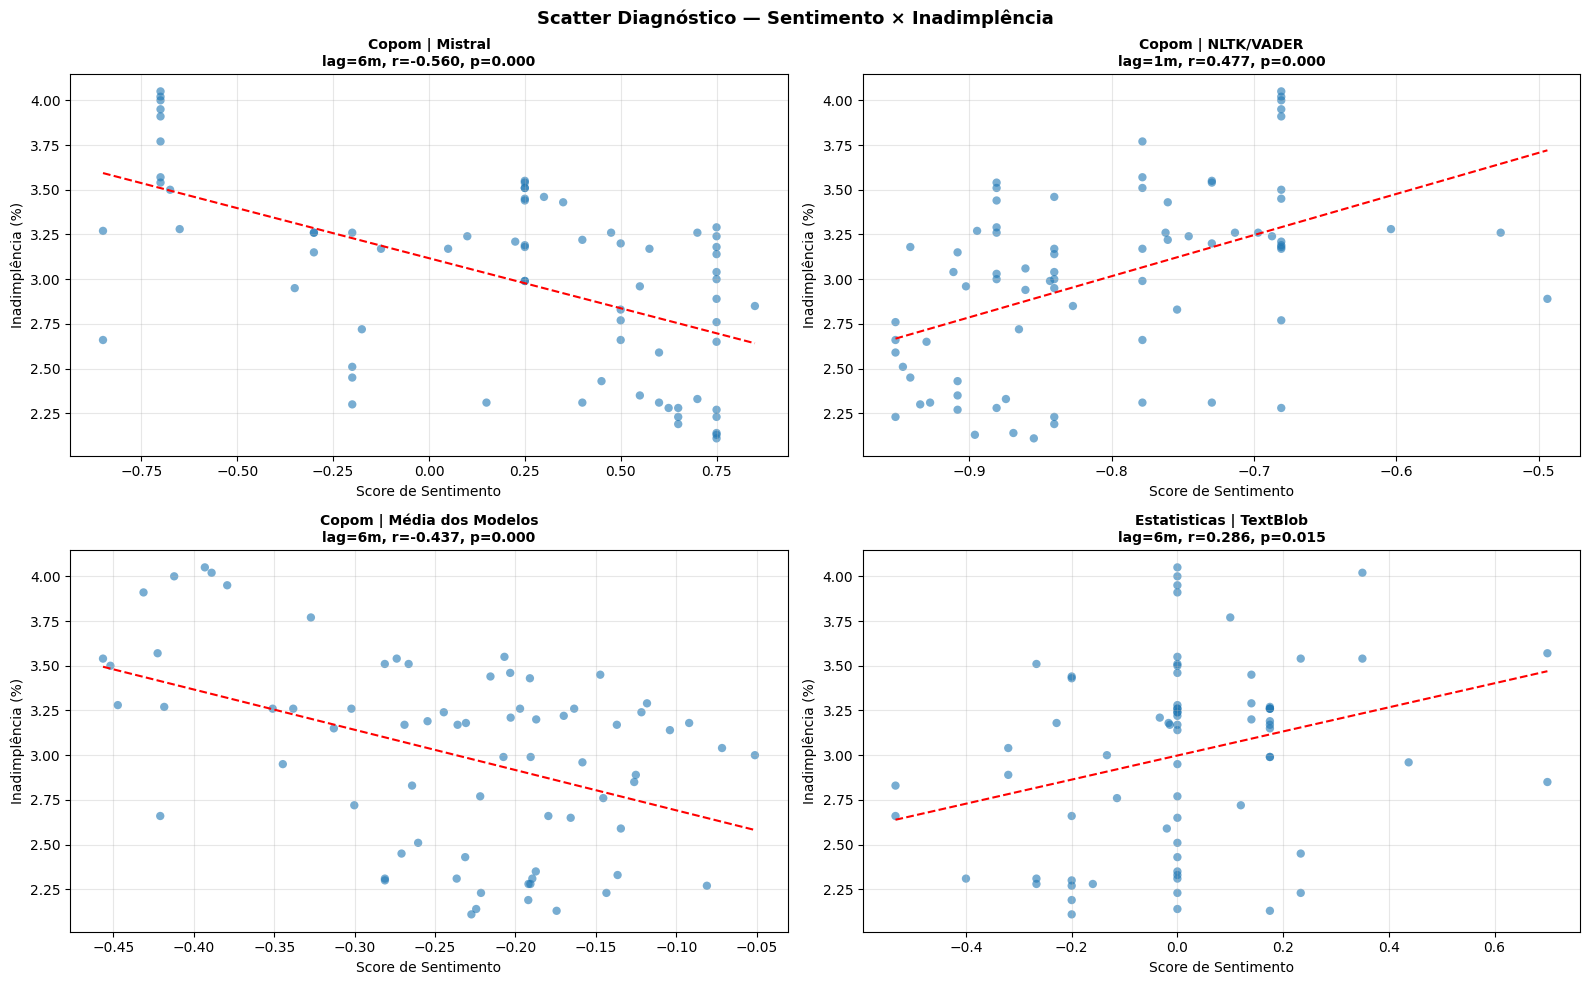

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top4_diagnostico.iterrows()):

    tipo_relatorio = row["Tipo Relatório"]
    col = row["col"]
    lag = int(row["Lag (meses)"])

    df_tipo = (
        df_merged[df_merged["tipo_relatorio"] == tipo_relatorio]
        .sort_values("mes")
        .copy()
    )

    df_tipo["sent_lag"] = df_tipo[col].shift(lag)

    df_tmp = df_tipo[["inad_total", "sent_lag"]].dropna().rename(
        columns={
            "inad_total": "inad",
            "sent_lag": "sent"
        }
    )

    if len(df_tmp) < 5:
        ax.set_title(f"{tipo_relatorio} | {nomes_display.get(col, col)}\nDados insuficientes")
        ax.axis("off")
        continue

    r, p = stats.pearsonr(df_tmp["inad"], df_tmp["sent"])

    ax.scatter(
        df_tmp["sent"],
        df_tmp["inad"],
        alpha=0.6,
        edgecolors="none"
    )

    z = np.polyfit(df_tmp["sent"], df_tmp["inad"], 1)
    x_line = np.linspace(df_tmp["sent"].min(), df_tmp["sent"].max(), 100)

    ax.plot(
        x_line,
        np.poly1d(z)(x_line),
        "r--",
        linewidth=1.5
    )

    ax.set_title(
        f"{tipo_relatorio.capitalize()} | {nomes_display.get(col, col)}\n"
        f"lag={lag}m, r={r:.3f}, p={p:.3f}",
        fontweight="bold",
        fontsize=10
    )

    ax.set_xlabel("Score de Sentimento")
    ax.set_ylabel("Inadimplência (%)")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Scatter Diagnóstico — Sentimento × Inadimplência",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()